In [78]:
import pandas as pd
from pathlib import Path

NOTEBOOK_DIR = Path().resolve()
base_file = NOTEBOOK_DIR / "all-MCU2.csv"
additional_file = NOTEBOOK_DIR / "gpt-5_sg_converted.csv"

if not base_file.exists():
    raise FileNotFoundError(f"Base CSV not found: {base_file}")
if not additional_file.exists():
    raise FileNotFoundError(f"Additional CSV not found: {additional_file}")

df_base = pd.read_csv(base_file)
df_g5 = pd.read_csv(additional_file)

df_base["source_file"] = base_file.name
df_g5["source_file"] = additional_file.name

df = pd.concat([df_base, df_g5], ignore_index=True, sort=False)

print(f"Loaded base rows: {len(df_base)}")
print(f"Loaded additional rows: {len(df_g5)}")
print(f"Merged rows: {len(df)}")

# Inline range summary for G5 ArdSG-only add-on data
latency_g5 = pd.to_numeric(df_g5.get("latency"), errors="coerce")
tokens_g5 = pd.to_numeric(df_g5.get("total_tokens"), errors="coerce")
cost_g5 = pd.to_numeric(df_g5.get("total_cost"), errors="coerce")

print("G5 data range (additional ArdSG set):")
if latency_g5.notna().any():
    print(f"- latency (s): {latency_g5.min():.2f} to {latency_g5.max():.2f}")
else:
    print("- latency (s): N/A")

if tokens_g5.notna().any():
    print(f"- total_tokens: {int(tokens_g5.min())} to {int(tokens_g5.max())}")
else:
    print("- total_tokens: N/A")

if cost_g5.notna().any():
    print(f"- total_cost (USD): {cost_g5.min():.6f} to {cost_g5.max():.6f}")
else:
    print("- total_cost (USD): N/A")

Loaded base rows: 630
Loaded additional rows: 30
Merged rows: 660
G5 data range (additional ArdSG set):
- latency (s): 154.13 to 370.24
- total_tokens: 11487 to 33629
- total_cost (USD): 0.086703 to 0.189412


In [79]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgba
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, PathPatch, Rectangle

# ==========================================
# 1. SETUP & DATA
# ==========================================
required_cols = ['processor', 'model', 'status', 'latency', 'total_tokens']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

for col in ['processor', 'model', 'status']:
    df[col] = df[col].astype(str).str.strip().str.lower()

# ==========================================
# 2. CONFIGURATION
# ==========================================
MODEL_LABELS = {
    'gpt-5': 'G5',
    'gpt-4o': 'G4o', 'gpt-4o-mini': 'G4o-m', 'qwen32': 'Qw32B', 'qwen14': 'Qw14B',
    'phi4': 'Phi4', 'codestral': 'Co22B', 'codestral-p': 'Co22B-p'
}
PROCESSOR_LABELS = {
    'dp': 'DP',
    'mc': 'MC',
    'sg': 'ArdSG',
    # 'psg': 'PySG-CPU',
    # 'tpusg': 'PySG-TPU',
}
# Build model order from data while preserving first-seen order.
mapped_displays = [MODEL_LABELS[m] if m in MODEL_LABELS else m for m in df['model'].dropna().unique()]
MODEL_ORDER_PREF = list(MODEL_LABELS.values())
PROCESSOR_ORDER_PREF = ['dp', 'mc', 'sg']
STATUS_ORDER = ['success', 'failure']

df['model_display'] = df['model'].map(MODEL_LABELS).fillna(df['model'])
print(MODEL_ORDER_PREF)

['G5', 'G4o', 'G4o-m', 'Qw32B', 'Qw14B', 'Phi4', 'Co22B', 'Co22B-p']


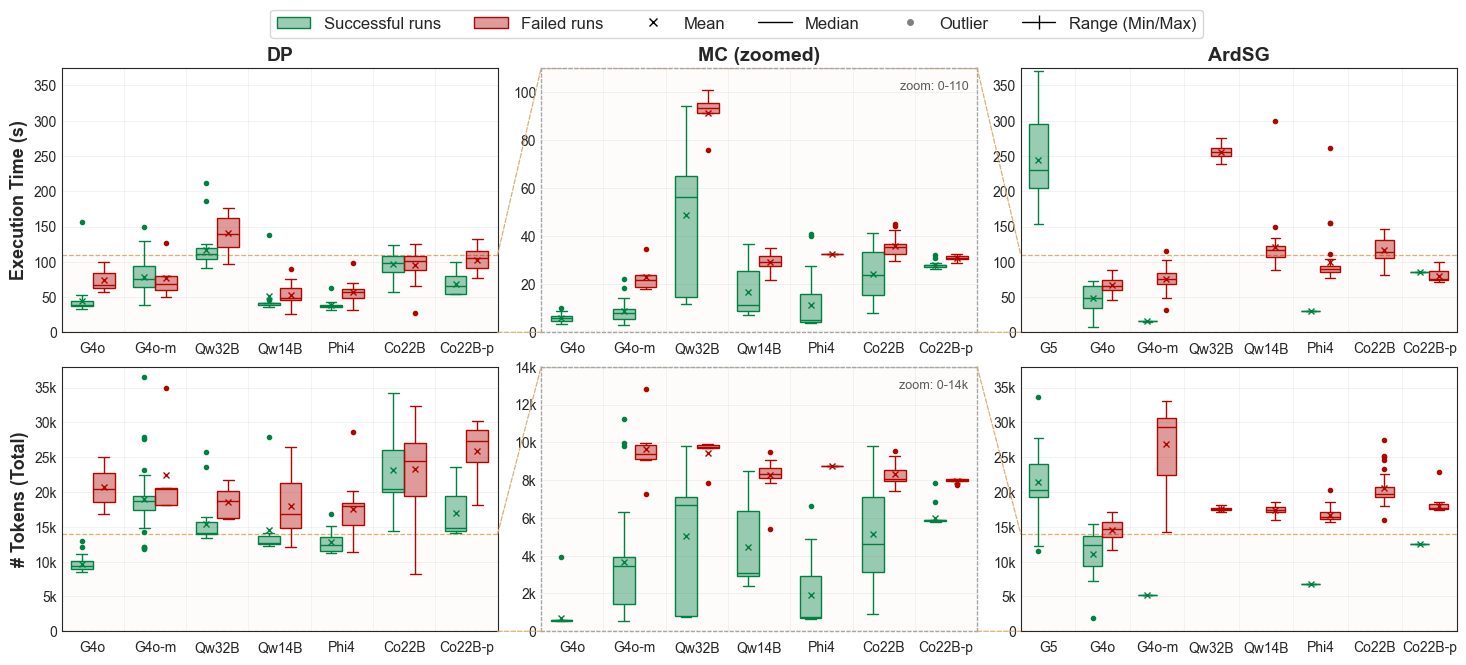

In [80]:

metrics = [
    {'col': 'latency', 'label': 'Execution Time (s)', 'fmt': None},
    {
        'col': 'total_tokens',
        'label': '# Tokens (Total)',
        'fmt': lambda x, _: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}"
    }
]

metric_limits = {
    'latency': (0, 375),
    'total_tokens': (0, 38000),
}

mc_metric_limits = {
    'latency': (0, 110),
    'total_tokens': (0, 14000),
}

# ==========================================
# 3. STYLE TOKENS (FONTS, SIZES, WEIGHTS, COLORS)
# ==========================================
FONT = {
    'family': 'Arial',
    'title_size': 14,
    'title_weight': 'bold',
    'label_size': 13,
    'label_weight': 'bold',
    'legend_size': 12,
    'zoom_note_size': 9,
}

COLORS = {
    'status_success_fill': '#008142',
    'status_success_edge': '#008142',
    'status_failure_fill': '#B10600',
    'status_failure_edge': '#B10600',
    'zoom_band': '#F5F0E6',
    'zoom_line': '#D9A66A',
    'group_separator': '0.85',
    'grid': '0.88',
    'zoom_spine': '0.65',
    'zoom_note_text': '0.35',
    'mean_marker': 'black',
    'median_line': 'black',
    'outlier': 'gray',
}

STYLE = {
    'group_separator_linewidth': 0.6,
    'group_separator_alpha': 0.35,
    'grid_linewidth': 0.6,
    'grid_alpha': 0.5,
    'box_linewidth': 1.0,
    'box_width': 0.7,
    'box_fill_alpha': 0.4,
    'mean_marker_size': 5,
    'outlier_marker_size': 3,
    'zoom_linewidth': 0.9,
    'zoom_line_alpha': 0.9,
    'mc_spine_linewidth': 1.0,
    'legend_columns': 6,
}

STATUS_STYLES = {
    'success': {
        'facecolor': COLORS['status_success_fill'],
        'edgecolor': COLORS['status_success_edge'],
    },
    'failure': {
        'facecolor': COLORS['status_failure_fill'],
        'edgecolor': COLORS['status_failure_edge'],
    },
}
palette = {status: style['facecolor'] for status, style in STATUS_STYLES.items()}

# Processor-specific x-axis model order: only ArdSG keeps G5 tick.
MODEL_ORDER_BY_PROC = {
    'dp': [m for m in MODEL_ORDER_PREF if m != 'G5'],
    'mc': [m for m in MODEL_ORDER_PREF if m != 'G5'],
    'sg': MODEL_ORDER_PREF,
}

# ==========================================
# 4. PLOTTING
# ==========================================
sns.set_style('white')
plt.rcParams['font.family'] = FONT['family']


def patch_x_bounds(ax, patch):
    (x0, _), (x1, _) = ax.transData.inverted().transform(patch.get_extents().get_points())
    return min(x0, x1), max(x0, x1)


def status_for_box_center(box_center, n_models):
    nearest_model_idx = min(
        range(max(n_models, 1)),
        key=lambda idx: abs(box_center - idx)
    )
    return STATUS_ORDER[0] if box_center <= nearest_model_idx else STATUS_ORDER[1]


def style_boxplot_by_status(ax, n_models):
    box_patches = [patch for patch in ax.patches if isinstance(patch, PathPatch)]
    if not box_patches:
        return

    box_specs = []
    for patch in box_patches:
        x0, x1 = patch_x_bounds(ax, patch)
        box_center = (x0 + x1) / 2
        status = status_for_box_center(box_center, n_models)
        style = STATUS_STYLES[status]
        fill_rgba = to_rgba(style['facecolor'], STYLE['box_fill_alpha'])
        edge_color = style['edgecolor']

        patch.set_facecolor(fill_rgba)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(STYLE['box_linewidth'])

        box_specs.append({
            'center': box_center,
            'x0': x0,
            'x1': x1,
            'edgecolor': edge_color,
        })

    line_tol = STYLE['box_width'] * 0.08
    for line in ax.lines:
        xdata = []
        for value in line.get_xdata():
            try:
                numeric_value = float(value)
            except (TypeError, ValueError):
                continue
            if math.isfinite(numeric_value):
                xdata.append(numeric_value)

        if not xdata:
            continue

        x_min = min(xdata)
        x_max = max(xdata)
        x_center = sum(xdata) / len(xdata)

        matches = [
            spec
            for spec in box_specs
            if x_min >= spec['x0'] - line_tol and x_max <= spec['x1'] + line_tol
        ]
        if not matches:
            continue

        spec = min(matches, key=lambda item: abs(x_center - item['center']))
        line.set_color(spec['edgecolor'])
        line.set_markeredgecolor(spec['edgecolor'])
        line.set_markerfacecolor(spec['edgecolor'])


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 7), sharey=False)
plt.subplots_adjust(top=0.915, hspace=0.13, wspace=0.1)

for col_idx, proc in enumerate(PROCESSOR_ORDER_PREF):
    subset = df[df['processor'] == proc]

    if subset.empty:
        for row_idx in range(len(metrics)):
            axes[row_idx, col_idx].set_visible(False)
        continue

    plot_order = MODEL_ORDER_BY_PROC.get(proc, MODEL_ORDER_PREF)

    for row_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        sns.boxplot(
            data=subset,
            x='model_display',
            y=metric['col'],
            hue='status',
            hue_order=STATUS_ORDER,
            order=plot_order,
            ax=ax,
            palette=palette,
            showmeans=True,
            meanprops={
                'marker': 'x',
                'markeredgecolor': COLORS['mean_marker'],
                'markersize': STYLE['mean_marker_size']
            },
            flierprops={
                'marker': 'o',
                'markersize': STYLE['outlier_marker_size'],
                'markerfacecolor': COLORS['outlier'],
                'markeredgecolor': COLORS['outlier']
            },
            width=STYLE['box_width'],
            linewidth=STYLE['box_linewidth']
        )
        style_boxplot_by_status(ax, len(plot_order))

        for xpos in np.arange(len(plot_order) - 1) + 0.5:
            ax.axvline(
                x=xpos,
                color=COLORS['group_separator'],
                linewidth=STYLE['group_separator_linewidth'],
                alpha=STYLE['group_separator_alpha'],
                zorder=0
            )

        if ax.get_legend():
            ax.get_legend().remove()
        ax.set_xlabel('')
        ax.grid(
            axis='y',
            color=COLORS['grid'],
            linewidth=STYLE['grid_linewidth'],
            linestyle='-',
            alpha=STYLE['grid_alpha']
        )

        ax.set_ylabel(
            metric['label'] if col_idx == 0 else '',
            fontweight=FONT['label_weight'],
            fontsize=FONT['label_size']
        )
        ax.tick_params(axis='y', pad=0)

        if row_idx == 0:
            title = PROCESSOR_LABELS.get(proc, proc)
            if proc == 'mc':
                title += ' (zoomed)'
            ax.set_title(
                title,
                fontsize=FONT['title_size'],
                weight=FONT['title_weight'],
                pad=5
            )

        if metric['fmt']:
            ax.yaxis.set_major_formatter(FuncFormatter(metric['fmt']))

        if proc == 'mc' and metric['col'] in mc_metric_limits:
            y0, y1 = mc_metric_limits[metric['col']]
            ax.set_ylim(y0, y1)

            for spine in ax.spines.values():
                spine.set_linestyle((0, (2, 2)))
                spine.set_linewidth(STYLE['mc_spine_linewidth'])
                spine.set_color(COLORS['zoom_spine'])

            range_label = (
                f"{int(y0)}-{int(y1/1000)}k"
                if metric['col'] == 'total_tokens'
                else f"{int(y0)}-{int(y1)}"
            )
            ax.text(
                0.98,
                0.95,
                f"zoom: {range_label}",
                transform=ax.transAxes,
                ha='right',
                va='top',
                fontsize=FONT['zoom_note_size'],
                color=COLORS['zoom_note_text']
            )
        elif metric['col'] in metric_limits:
            ax.set_ylim(*metric_limits[metric['col']])

# ==========================================
# 5. ZOOM-LINK INDICATORS (MC <-> DP/ArdSG)
# ==========================================
for row_idx, metric in enumerate(metrics):
    metric_col = metric['col']
    y0, y1 = mc_metric_limits[metric_col]

    dp_ax = axes[row_idx, 0]
    mc_ax = axes[row_idx, 1]
    sg_ax = axes[row_idx, 2]

    dp_ax.axhspan(y0, y1, color=COLORS['zoom_band'], alpha=0.20, zorder=0)
    sg_ax.axhspan(y0, y1, color=COLORS['zoom_band'], alpha=0.20, zorder=0)

    mc_ax.set_facecolor(COLORS['zoom_band'])
    mc_ax.patch.set_alpha(0.20)

    for ax in [dp_ax, mc_ax, sg_ax]:
        ax.axhline(
            y=y0,
            color=COLORS['zoom_line'],
            linewidth=STYLE['zoom_linewidth'],
            linestyle='--',
            alpha=STYLE['zoom_line_alpha'],
            zorder=0
        )
        ax.axhline(
            y=y1,
            color=COLORS['zoom_line'],
            linewidth=STYLE['zoom_linewidth'],
            linestyle='--',
            alpha=STYLE['zoom_line_alpha'],
            zorder=0
        )

    for src_ax, dst_ax in [(dp_ax, mc_ax), (mc_ax, sg_ax)]:
        for y in (y0, y1):
            fig.add_artist(ConnectionPatch(
                xyA=(1.0, y), coordsA=src_ax.get_yaxis_transform(),
                xyB=(0.0, y), coordsB=dst_ax.get_yaxis_transform(),
                color=COLORS['zoom_line'],
                linewidth=STYLE['zoom_linewidth'],
                linestyle='--',
                alpha=STYLE['zoom_line_alpha']
            ))

# ==========================================
# 6. CUSTOM LEGEND
# ==========================================
legend_elements = [
    Rectangle(
        (0, 0), 1, 1,
        facecolor=to_rgba(COLORS['status_success_fill'], STYLE['box_fill_alpha']),
        edgecolor=COLORS['status_success_edge'],
        linewidth=STYLE['box_linewidth'],
        label='Successful runs'
    ),
    Rectangle(
        (0, 0), 1, 1,
        facecolor=to_rgba(COLORS['status_failure_fill'], STYLE['box_fill_alpha']),
        edgecolor=COLORS['status_failure_edge'],
        linewidth=STYLE['box_linewidth'],
        label='Failed runs'
    ),
    Line2D([0], [0], color=COLORS['mean_marker'], marker='x', linestyle='None', markersize=6, label='Mean'),
    Line2D([0], [0], color=COLORS['median_line'], linewidth=1, linestyle='-', label='Median'),
    Line2D([0], [0], color=COLORS['outlier'], marker='o', linestyle='None', markersize=4, label='Outlier'),
    Line2D([0], [0], color=COLORS['median_line'], linewidth=1, linestyle='-', marker='|', markersize=10, label='Range (Min/Max)')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=STYLE['legend_columns'],
    bbox_to_anchor=(0.5, 1.01),
    fontsize=FONT['legend_size'],
    frameon=True
)
file_path = 'figs/with-g5-box_MCU'

plt.savefig(file_path+'.pdf', dpi=300, bbox_inches='tight')
plt.savefig(file_path+'.png', dpi=300, bbox_inches='tight')
plt.show()


In [81]:
from pathlib import Path
import pandas as pd
import numpy as np

# Resolve data directory (works from repo root or notebook folder)
DATA_DIR = Path().resolve()
base_csv_file = DATA_DIR / "all-MCU2.csv"
additional_csv_file = DATA_DIR / "gpt-5_sg_converted.csv"

if not base_csv_file.exists():
    raise FileNotFoundError(f"Base CSV file not found: {base_csv_file}")
if not additional_csv_file.exists():
    raise FileNotFoundError(f"Additional CSV file not found: {additional_csv_file}")

# Canonical labels and ordering (single source of truth)
MODEL_LABELS = {
    "gpt-5": "G5",
    "gpt-4o": "G4o",
    "gpt-4o-mini": "G4o-m",
    "phi4": "Phi4",
    "qwen32": "Qw32B",
    "qwen14": "Qw14B",
    "codestral": "Co22B",
    "codestral-p": "Co22B-p",
    "gemma3": "Ge3",
}
PROCESSOR_LABELS = { "dp": "DP",
                    "mc": "MC",
                    "sg": "ArdSG",
                    "psg": "PySG-CPU",
                    "tpusg": "PySG-TPU",}

MODEL_ORDER_PREF = list(MODEL_LABELS.keys())
PROCESSOR_ORDER_PREF = list(PROCESSOR_LABELS.keys())

required_cols = {"status", "latency", "processor", "model"}

df_base = pd.read_csv(base_csv_file)
df_additional = pd.read_csv(additional_csv_file)

df_base["source_file"] = base_csv_file.name
df_additional["source_file"] = additional_csv_file.name

# Merge base + additional rows (asymmetric G5-only ArdSG additions come from the second file)
df = pd.concat([df_base, df_additional], ignore_index=True, sort=False)
df.columns = df.columns.str.strip()

missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Merged dataframe is missing required columns: {sorted(missing)}")

df = df.copy()
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["status_group"] = np.where(df["status"] == "success", "success", "failure")
df["processor_std"] = df["processor"].astype(str).str.strip().str.lower()
df["model_std"] = df["model"].astype(str).str.strip().str.lower()
df["latency"] = pd.to_numeric(df["latency"], errors="coerce")
if "total_cost" not in df.columns:
    df["total_cost"] = np.nan
df["total_cost"] = pd.to_numeric(df["total_cost"], errors="coerce")
if "total_tokens" not in df.columns:
    df["total_tokens"] = np.nan
df["total_tokens"] = pd.to_numeric(df["total_tokens"], errors="coerce")

keep_cols = [
    "model_std",
    "processor_std",
    "status_group",
    "latency",
    "total_cost",
    "total_tokens",
    "source_file",
    "model",
    "processor",
    "status",
]
df = df[keep_cols]

# Sanity checks for added G5-ArdSG data
g5_sg_rows = df[(df["model_std"] == "gpt-5") & (df["processor_std"] == "sg")]
g5_non_sg_rows = df[(df["model_std"] == "gpt-5") & (df["processor_std"] != "sg")]
g5_failures = g5_sg_rows[g5_sg_rows["status_group"] == "failure"]

if g5_sg_rows.empty:
    raise ValueError("No merged rows found for model='gpt-5' and processor='sg'.")
if len(g5_non_sg_rows) > 0:
    print(f"Warning: Found {len(g5_non_sg_rows)} G5 rows outside ArdSG; they will not be used for asymmetric additions.")
if len(g5_failures) > 0:
    print(f"Warning: Found {len(g5_failures)} G5 ArdSG failure rows; expected zero by spec.")

print(f"Loaded base rows: {len(df_base)}")
print(f"Loaded additional rows: {len(df_additional)}")
print(f"Merged rows: {len(df)}")
print(f"G5 ArdSG rows: {len(g5_sg_rows)}")

Loaded base rows: 630
Loaded additional rows: 30
Merged rows: 660
G5 ArdSG rows: 30


In [82]:
import pprint

# ═══════════════════════════════════════════════════════════════════════════
# STEP 1: Determine model and processor order
# ═══════════════════════════════════════════════════════════════════════════
models_present = list(df["model_std"].unique())
processors_present = list(df["processor_std"].unique())

model_order = [m for m in MODEL_ORDER_PREF if m in models_present] + [
    m for m in models_present if m not in MODEL_ORDER_PREF
]
processor_order = [p for p in PROCESSOR_ORDER_PREF if p in processors_present] + [
    p for p in processors_present if p not in PROCESSOR_ORDER_PREF
]

# ═══════════════════════════════════════════════════════════════════════════
# STEP 2: Calculate success rates
# ═══════════════════════════════════════════════════════════════════════════
pivot_data = (
    df.groupby(["model_std", "processor_std", "status_group"])
    .size()
    .unstack(fill_value=0)
)

for missing_col in ("success", "failure"):
    if missing_col not in pivot_data.columns:
        pivot_data[missing_col] = 0

success_rate_dict = {}
for (model, processor), row in pivot_data.iterrows():
    success_count = int(row.get("success", 0))
    failure_count = int(row.get("failure", 0))
    total = success_count + failure_count
    rate = success_count / total if total else 0.0
    success_rate_dict[(model, processor)] = {
        "success_count": success_count,
        "failure_count": failure_count,
        "total": total,
        "success_rate": rate,
    }

print("Success rate summary (fraction):")
pprint.pprint(success_rate_dict)

# ═══════════════════════════════════════════════════════════════════════════
# STEP 3: Aggregate latency and cost metrics by model
# ═══════════════════════════════════════════════════════════════════════════
def _agg_mean(frame: pd.DataFrame, metric: str):
    """Aggregate mean of a metric grouped by processor."""
    if frame.empty or metric not in frame:
        return {p: 0.0 for p in processor_order}
    return (
        frame.groupby("processor_std")[metric]
        .mean()
        .reindex(processor_order)
        .fillna(0.0)
        .to_dict()
    )


def build_model_dict(model_key: str):
    """Build latency and cost statistics for a given model."""
    subset = df[df["model_std"] == model_key]
    if subset.empty:
        return {"latency": {}, "cost": {}}

    df_pass = subset[subset["status_group"] == "success"]
    df_fail = subset[subset["status_group"] != "success"]

    pass_latency = _agg_mean(df_pass, "latency")
    fail_latency = _agg_mean(df_fail, "latency")
    pass_cost = _agg_mean(df_pass, "total_cost")
    fail_cost = _agg_mean(df_fail, "total_cost")

    def safe_mean(frame, metric):
        if frame.empty or frame[metric].dropna().empty:
            return 0.0
        return float(frame[metric].mean())

    return {
        "latency": {
            **pass_latency,
            "total": safe_mean(df_pass, "latency"),
            "total_x": safe_mean(df_fail, "latency"),
        },
        "cost": {
            **pass_cost,
            "total": safe_mean(df_pass, "total_cost"),
            "total_x": safe_mean(df_fail, "total_cost"),
        },
    }

# ═══════════════════════════════════════════════════════════════════════════
# STEP 4: Select GPT models for comparison and build their statistics
# ═══════════════════════════════════════════════════════════════════════════
models_by_volume = df["model_std"].value_counts().index.tolist()
gpt_models = [m for m in models_by_volume if "gpt" in m.lower() and m != "gpt-5"]
if not gpt_models:
    raise ValueError("No non-G5 GPT models found for base comparison plot.")

primary_model = gpt_models[0]
secondary_model = gpt_models[1] if len(gpt_models) > 1 else None

primary_stats = build_model_dict(primary_model)
secondary_stats = build_model_dict(secondary_model) if secondary_model else None

# Targeted asymmetric add-on: G5 in ArdSG success only
g5_sg_success_df = df[
    (df["model_std"] == "gpt-5")
    & (df["processor_std"] == "sg")
    & (df["status_group"] == "success")
]
g5_sg_time = float(g5_sg_success_df["latency"].mean()) if not g5_sg_success_df.empty else np.nan
g5_sg_cost = float(g5_sg_success_df["total_cost"].mean()) if not g5_sg_success_df.empty else np.nan

# ═══════════════════════════════════════════════════════════════════════════
# STEP 5: Scale cost values for better visualization (convert to cents)
# ═══════════════════════════════════════════════════════════════════════════
COST_SCALE = 100
primary_stats["cost"] = {k: (v or 0) * COST_SCALE for k, v in primary_stats["cost"].items()}
if secondary_stats:
    secondary_stats["cost"] = {k: (v or 0) * COST_SCALE for k, v in secondary_stats["cost"].items()}
g5_sg_cost_cents = g5_sg_cost * COST_SCALE if pd.notna(g5_sg_cost) else np.nan

print("\n" + "=" * 80)
print("Primary model:", MODEL_LABELS.get(primary_model, primary_model))
print("=" * 80)
pprint.pprint(primary_stats)
if secondary_stats:
    print("\n" + "=" * 80)
    print("Secondary model:", MODEL_LABELS.get(secondary_model, secondary_model))
    print("=" * 80)
    pprint.pprint(secondary_stats)

print("\nAsymmetric G5 add-on (ArdSG success only):")
print({"g5_sg_time": g5_sg_time, "g5_sg_cost_cents": g5_sg_cost_cents})

Success rate summary (fraction):
{('codestral', 'dp'): {'failure_count': 19,
                       'success_count': 11,
                       'success_rate': 0.36666666666666664,
                       'total': 30},
 ('codestral', 'mc'): {'failure_count': 14,
                       'success_count': 16,
                       'success_rate': 0.5333333333333333,
                       'total': 30},
 ('codestral', 'sg'): {'failure_count': 30,
                       'success_count': 0,
                       'success_rate': 0.0,
                       'total': 30},
 ('codestral-p', 'dp'): {'failure_count': 12,
                         'success_count': 18,
                         'success_rate': 0.6,
                         'total': 30},
 ('codestral-p', 'mc'): {'failure_count': 6,
                         'success_count': 24,
                         'success_rate': 0.8,
                         'total': 30},
 ('codestral-p', 'sg'): {'failure_count': 29,
                         'succe

figure size: 8.0 x 4.5


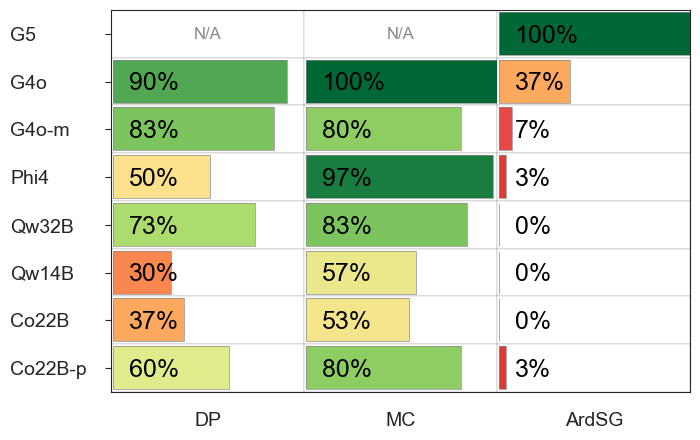

In [83]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# plt.rcParams["font.family"] = "Arial"

# Build dataframe again to stay in sync even if previous cell is skipped
heatmap_df = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS.get(model, model),
            "processor": processor,
            "success_rate": (data["success_rate"] * 100)
            if data["success_rate"] <= 1
            else data["success_rate"],
        }
        for (model, processor), data in success_rate_dict.items()
    ],
)

heatmap_df = heatmap_df.pivot(index="model", columns="processor", values="success_rate")
heatmap_df = heatmap_df.reindex(
    index=[MODEL_LABELS.get(m, m) for m in model_order],
    columns=processor_order,
)

plt.rcParams["font.family"] = "Arial"

# Dynamic figure sizing based on number of models and processors
num_models = len(heatmap_df.index)
num_processors = len(heatmap_df.columns)
fig_width = max(5.0, num_processors * 1.5)
fig_height = max(3.0, num_models * 0.5)
fig_width = 8
fig_height = 4.5
print(f"figure size: {fig_width:.1f} x {fig_height:.1f}")
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

cmap = LinearSegmentedColormap.from_list(
    "custom",
    [
        "#D73027",
        "#F65D5F",
        "#F46D43",
        "#FDAE61",
        "#FEE08B",
        "#D9EF8B",
        "#A6D96A",
        "#68BA59",
        "#006837",
    ],
    N=256,
)

ax.set_xlim(0, len(heatmap_df.columns))
ax.set_ylim(0, len(heatmap_df.index))
ax.invert_yaxis()

bar_height_ratio = 0.9
gap = 0
null_symbol = "N/A"

for i, model in enumerate(heatmap_df.index):
    for j, processor in enumerate(heatmap_df.columns):
        value = heatmap_df.loc[model, processor]

        bg_rect = mpatches.Rectangle(
            (j + gap / 2, i + gap / 2),
            1 - gap,
            1 - gap,
            facecolor="white",
            edgecolor="black",
            linewidth=0.1,
        )
        ax.add_patch(bg_rect)

        if pd.notna(value):
            bar_color = cmap(value / 100)
            bar_height = bar_height_ratio
            y_offset = (1 - bar_height) / 2 - 0.01
            x_offset = 0.01
            bar_width = value / 100

            bar_rect = mpatches.Rectangle(
                (j + x_offset, i + y_offset),
                bar_width,
                bar_height,
                facecolor=bar_color,
                edgecolor="none",
                linewidth=0,
            )
            ax.add_patch(bar_rect)

            bar_border = mpatches.Rectangle(
                (j + x_offset, i + y_offset),
                bar_width,
                bar_height,
                facecolor="none",
                edgecolor="#888888",
                linewidth=0.5,
            )
            ax.add_patch(bar_border)

            ax.text(
                j + 0.09,
                i + 0.55,
                f"{value:.0f}%",
                ha="left",
                va="center",
                fontsize=18,
                weight="regular",
                color="black",
            )
        else:
            # Explicit symbol for missing stage-model pair (null, not 0%)
            ax.text(
                j + 0.5,
                i + 0.52,
                null_symbol,
                ha="center",
                va="center",
                fontsize=12,
                weight="regular",
                color="#8a8a8a",
            )

ax.set_xticks([i + 0.5 for i in range(len(heatmap_df.columns))])
ax.set_yticks([i + 0.5 for i in range(len(heatmap_df.index))])
ax.set_xticklabels(
    [PROCESSOR_LABELS.get(col, col) for col in heatmap_df.columns],
    fontsize=14,
    weight="regular",
)
ax.set_yticklabels(heatmap_df.index, fontsize=14)
for label in ax.get_yticklabels():
    label.set_horizontalalignment("left")
    label.set_x(-0.18)

# Explicitly restore left y-axis ticks after seaborn white-style settings.
ax.tick_params(axis="y", which="both", left=True, length=4, width=0.8, pad=-6)
ax.tick_params(axis="x", which="both", pad=11)

# Keep only the left spine visible for the heatmap axis frame.
ax.spines["left"].set_visible(True)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["bottom"].set_visible(True)

# ax.set_xlabel("Stages", fontsize=13, weight="regular", labelpad=5, color="gray", x=0.4)
# ax.set_ylabel("Models", fontsize=13, weight="regular", labelpad=5, color="gray", x=0.03)

plt.subplots_adjust(left=0.22)
plt.tight_layout(rect=[0.12, 0, 1, 1])
plt.savefig("figs/with-additional-g5-success-rate_MCU.pdf", dpi=300, bbox_inches="tight")

plt.show()

Figure size: 8.0 x 5.8


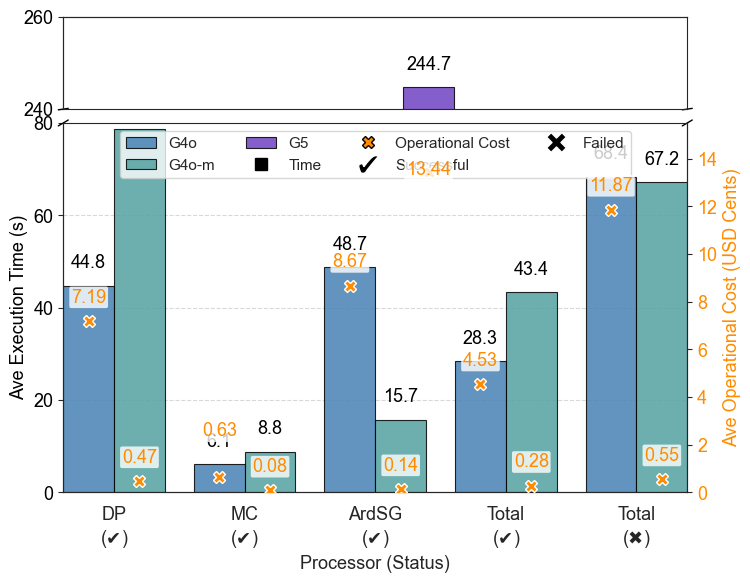


Plot saved as 'figs/g5-g4o-g4om_mcu_comparison.pdf' with dpi=300 and bbox_inches='tight'


In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

# =============================================================================
# Styling and visual tuning parameters (centralized)
# =============================================================================
COLORS = {
    "primary_bar": "steelblue",
    "secondary_bar": "#54a1a1",
    "g5_bar": "#6f42c1",
    "cost_annotation": "darkorange",
    "background": "#ffffff",
    "text": "#000000",
    "time_axis": "black",
    "grid": "gray",
    "cost_marker_edge": "white",
    "cost_label_box": "white",
    "cost_label_box_edge": "none",
    "legend_cost_marker_edge": "black",
}
COLORS["cost_axis"] = COLORS["cost_annotation"]
COLORS["legend_cost_marker_face"] = COLORS["cost_annotation"]

FONT = {
    "family": "Arial",
    "family2": "Arial",
    "base": 13,
    "weight_regular": "regular",
    "label_weight": "regular",
    "ylabel_plus": 0,
    "xtick_plus": 0,
    "cost_label_minus": 0,
    "legend_minus": 2,
}
plt.rcParams["font.family"] = FONT["family2"]

FIGURE = {
    "min_width": 8.0,
    "width_per_category": 0.75,
    "base_height": 5.2,
    "height_per_category": 0.12,
    "marker_size_base": 8,
    "marker_size_width_scale": 0.4,
    "marker_size_width_offset": 5.0,
}

BARS = {
    "max_width": 0.35,
    "total_span": 0.8,
    "edgecolor": "black",
    "linewidth": 0.8,
    "alpha": 0.85,
    "zorder": 3,
}

AXIS = {
    "time_label": "Ave Execution Time (s)",
    "cost_label": "Ave Operational Cost (USD Cents)",
    "xlabel": "Processor (Status)",
    "x_tick_pad": 10,
    "grid_linestyle": "--",
    "grid_alpha": 0.3,
    "grid_zorder": 0,
    "time_nbins": 5,
    "break_tick_step": 20.0,
}

COST_ANNOTATION = {
    "marker": "X",
    "marker_edge_width": 1,
    "marker_zorder": 5,
    "time_label_offset_ratio": 0.01,
    "cost_label_default_offset_ratio": 0.04,
    "cost_label_low_marker_offset_ratio": 0.10,
    "cost_label_low_marker_trigger_ratio": 0.15,
    "text_height_ratio": 0.08,
    "overlap_margin_ratio": 1.2,
    "time_overlap_buffer_ratio": 0.3,
    "horizontal_threshold_width_ratio": 1.5,
    "max_attempts": 10,
    "max_label_height_ratio": 0.85,
    "fallback_below_marker_ratio": 0.05,
    "fallback_min_ratio": 0.02,
    "cost_box_style": "round,pad=0.1",
    "cost_box_alpha": 0.8,
    "cost_text_format": "{cost:.2f}",
    "time_text_format": "{time:.1f}",
    "cost_text_ha": "center",
    "cost_text_va": "bottom",
    "time_text_ha": "center",
    "time_text_va": "bottom",
}

LEGEND = {
    "loc": "upper center",
    "frameon": True,
    "fancybox": True,
    "shadow": False,
    "ncol": 4,
    "time_label": "Time",
    "cost_label": "Operational Cost",
    "success_label": "Successful",
    "fail_label": "Failed",
    "success_marker": "$✔$",
    "fail_marker": "$✖$",
}



# Data setup
keys = processor_order + ["total", "total_x"]
categories = [f"{PROCESSOR_LABELS.get(p, p)}\n($✔$)" for p in processor_order] + ["Total\n($✔$)", "Total\n($✖$)"]

# Force model ordering in bars/legend: GPT-4o first, GPT-4o-mini second
model_stats_by_key = {}
if primary_model and primary_stats:
    model_stats_by_key[primary_model] = primary_stats
if secondary_model and secondary_stats:
    model_stats_by_key[secondary_model] = secondary_stats

ordered_model_keys = [m for m in ("gpt-4o", "gpt-4o-mini") if m in model_stats_by_key]
ordered_model_keys += [m for m in model_stats_by_key if m not in ordered_model_keys]

if not ordered_model_keys:
    raise ValueError("No model stats available for the cost/time comparison plot.")

first_model = ordered_model_keys[0]
first_stats = model_stats_by_key[first_model]
first_label = MODEL_LABELS.get(first_model, first_model)

second_model = ordered_model_keys[1] if len(ordered_model_keys) > 1 else None
second_stats = model_stats_by_key[second_model] if second_model else None
second_label = MODEL_LABELS.get(second_model, second_model) if second_model else None

# Extract metrics as arrays
def extract_metrics(stats, keys):
    return (
        np.array([stats["latency"].get(k, 0) for k in keys]),
        np.array([stats["cost"].get(k, 0) for k in keys]),
    )


times_first, costs_first = extract_metrics(first_stats, keys)
times_second, costs_second = (
    extract_metrics(second_stats, keys)
    if second_stats
    else (np.zeros_like(times_first), np.zeros_like(costs_first))
)

# Chart dimensions
num_categories = len(categories)
series_count = len(ordered_model_keys)
fig_width = max(FIGURE["min_width"], num_categories * FIGURE["width_per_category"])
fig_height = FIGURE["base_height"] + FIGURE["height_per_category"] * num_categories
print(f"Figure size: {fig_width} x {fig_height}")
font_base = FONT["base"]
marker_size = FIGURE["marker_size_base"] + (fig_width - FIGURE["marker_size_width_offset"]) * FIGURE["marker_size_width_scale"]

# Calculate axis limits
def nice_limit(value, pct_pad, step):
    return float(np.ceil(max(value, step) * (1 + pct_pad) / step) * step)


max_time_candidates = [times_first.max(), times_second.max()]
max_cost_candidates = [costs_first.max(), costs_second.max()]
if pd.notna(g5_sg_time):
    max_time_candidates.append(g5_sg_time)
if pd.notna(g5_sg_cost_cents):
    max_cost_candidates.append(g5_sg_cost_cents)

max_time = np.nanmax(max_time_candidates)
max_cost = np.nanmax(max_cost_candidates)
y_max_time = nice_limit(max_time, 0.2, 5)
y_max_cost = nice_limit(max_cost, 0.15, 0.5)

# Broken axis configuration for left y-axis (time)
y_break_low = 80.0
y_break_high = 240.0
y_top_cap = 260.0
tick_step = AXIS["break_tick_step"]
use_broken_axis = y_max_time > y_break_high

# Setup figure
x = np.arange(num_categories) * 0.9
width = min(BARS["max_width"], BARS["total_span"] / max(series_count, 1))
offset = width / 2 if series_count == 2 else 0.0

if use_broken_axis:
    top_range = max(y_top_cap - y_break_high, tick_step)
    bottom_range = max(y_break_low, tick_step)

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = fig.add_gridspec(2, 1, height_ratios=[top_range, bottom_range], hspace=0.06)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

    ax_bot.set_facecolor(COLORS["background"])
    ax_bot.grid(
        axis="y",
        linestyle=AXIS["grid_linestyle"],
        alpha=AXIS["grid_alpha"],
        color=COLORS["grid"],
        zorder=AXIS["grid_zorder"],
    )
    ax_top.set_facecolor(COLORS["background"])
    ax_top.grid(False)

    ax_top.set_ylim(y_break_high, y_top_cap)
    ax_bot.set_ylim(0, y_break_low)

    ax_bot.set_yticks(np.arange(0, y_break_low + 0.1, tick_step))
    ax_top.set_yticks(np.array([y_break_high, y_top_cap]))

    ax_top.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)
    ax_top.tick_params(labelbottom=False, bottom=False)

    # Left-side break indicator only.
    d = 0.008
    kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1.0)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    # Keep right axis as a single continuous scale.
    ax2_top = ax_top.twinx()
    ax2_top.set_yticks([])
    ax2_top.spines["right"].set_visible(False)

    ax2_bot = ax_bot.twinx()
    ax2_bot.set_ylim(0, y_max_cost)

    primary_axes = (ax_top, ax_bot)
else:
    fig, ax_bot = plt.subplots(figsize=(fig_width, fig_height))
    ax_bot.set_facecolor(COLORS["background"])
    ax_bot.grid(
        axis="y",
        linestyle=AXIS["grid_linestyle"],
        alpha=AXIS["grid_alpha"],
        color=COLORS["grid"],
        zorder=AXIS["grid_zorder"],
    )
    ax_bot.set_ylim(0, y_max_time)
    ax2_bot = ax_bot.twinx()
    ax2_bot.set_ylim(0, y_max_cost)
    primary_axes = (ax_bot,)

fig.patch.set_facecolor(COLORS["background"])


def draw_series_on_axes(y_values, x_positions, color, label, draw_label=True):
    bars_refs = []
    for idx_ax, ax in enumerate(primary_axes):
        plotted_values = y_values
        if use_broken_axis:
            if ax is ax_bot:
                plotted_values = np.where(y_values <= y_break_low, y_values, np.nan)
            else:
                plotted_values = np.where(y_values >= y_break_high, y_values, np.nan)
        bars = ax.bar(
            x_positions,
            plotted_values,
            width,
            color=color,
            edgecolor=BARS["edgecolor"],
            linewidth=BARS["linewidth"],
            alpha=BARS["alpha"],
            zorder=BARS["zorder"],
            label=label if (idx_ax == len(primary_axes) - 1 and draw_label) else "_nolegend_",
        )
        if idx_ax == len(primary_axes) - 1:
            bars_refs = bars
    return bars_refs


bars_first = draw_series_on_axes(times_first, x - offset, COLORS["primary_bar"], f"{first_label}")
bars_second = (
    draw_series_on_axes(times_second, x + offset, COLORS["secondary_bar"], f"{second_label}")
    if second_stats
    else []
)

# Asymmetric add-on: single G5 bar in ArdSG-success cluster only
g5_bars = []
g5_times = np.array([])
g5_costs = np.array([])
if "sg" in processor_order and pd.notna(g5_sg_time):
    sg_idx = processor_order.index("sg")
    g5_x = x[sg_idx] + (width * 1.05)
    g5_bars = draw_series_on_axes(
        np.array([g5_sg_time]),
        np.array([g5_x]),
        COLORS["g5_bar"],
        MODEL_LABELS.get("gpt-5", "gpt-5"),
    )
    g5_times = np.array([g5_sg_time])
    g5_costs = np.array([g5_sg_cost_cents])
else:
    print("Warning: Skipped G5 single-bar add-on because ArdSG or G5 success metric is unavailable.")

# Configure axes labels/ticks
ax_main = primary_axes[-1]
ax_main.set_ylabel(
    AXIS["time_label"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
    color=COLORS["time_axis"],
)
ax_main.set_xticks(x)
ax_main.set_xticklabels(
    categories,
    fontsize=font_base + FONT["xtick_plus"],
    fontweight=FONT["weight_regular"],
)
ax_main.tick_params(axis="y", labelsize=font_base, labelcolor=COLORS["time_axis"])
ax_main.tick_params(axis="x", length=0, pad=AXIS["x_tick_pad"])

for ax in primary_axes:
    ax.tick_params(axis="y", labelsize=font_base, labelcolor=COLORS["time_axis"])
    if not use_broken_axis:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=AXIS["time_nbins"]))
    ax.set_xlim(-width, x[-1] + width)

ax_cost = ax2_bot
ax_cost.set_ylabel(
    AXIS["cost_label"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
    color=COLORS["cost_axis"],
)
ax_cost.tick_params(axis="y", labelsize=font_base, labelcolor=COLORS["cost_axis"])

# Add markers/labels
placed_cost_labels = []


def visible_y_for_time(y):
    if not use_broken_axis:
        return y
    if y_break_low < y < y_break_high:
        return y_break_low - 0.8
    if y > y_top_cap:
        return y_top_cap - 0.8
    return y


def axis_for_time(y):
    if not use_broken_axis:
        return primary_axes[0]
    if y <= y_break_low:
        return ax_bot
    return ax_top


def add_annotations(bars, times, costs):
    if not bars:
        return

    for idx, (bar, time, cost) in enumerate(zip(bars, times, costs), start=1):
        if not np.isfinite(time) or not np.isfinite(cost):
            continue

        x_center = bar.get_x() + bar.get_width() / 2

        # Cost marker and label on right-axis scale only
        ax_cost.plot(
            x_center,
            cost,
            marker=COST_ANNOTATION["marker"],
            color=COLORS["cost_annotation"],
            markersize=marker_size,
            markeredgecolor=COLORS["cost_marker_edge"],
            markeredgewidth=COST_ANNOTATION["marker_edge_width"],
            zorder=COST_ANNOTATION["marker_zorder"],
            clip_on=True,
        )

        cost_label_y = cost + y_max_cost * COST_ANNOTATION["cost_label_default_offset_ratio"]
        cost_overlap_threshold = y_max_cost * COST_ANNOTATION["text_height_ratio"] * COST_ANNOTATION["overlap_margin_ratio"]

        horizontal_threshold = width * COST_ANNOTATION["horizontal_threshold_width_ratio"]
        for _ in range(COST_ANNOTATION["max_attempts"]):
            has_overlap = False
            for placed_x, placed_y in placed_cost_labels:
                if abs(x_center - placed_x) < horizontal_threshold and abs(cost_label_y - placed_y) < cost_overlap_threshold:
                    cost_label_y = placed_y + cost_overlap_threshold
                    has_overlap = True
                    break
            if not has_overlap:
                break

        cost_label_y = min(cost_label_y, y_max_cost * COST_ANNOTATION["max_label_height_ratio"])
        placed_cost_labels.append((x_center, cost_label_y))

        ax_cost.text(
            x_center,
            cost_label_y,
            COST_ANNOTATION["cost_text_format"].format(cost=cost),
            ha=COST_ANNOTATION["cost_text_ha"],
            va=COST_ANNOTATION["cost_text_va"],
            fontsize=font_base - FONT["cost_label_minus"],
            fontweight=FONT["label_weight"],
            color=COLORS["cost_annotation"],
            bbox=dict(
                boxstyle=COST_ANNOTATION["cost_box_style"],
                fc=COLORS["cost_label_box"],
                ec=COLORS["cost_label_box_edge"],
                alpha=COST_ANNOTATION["cost_box_alpha"],
            ),
            zorder=6,
            clip_on=True,
        )

        # Time label on broken left axis
        time_label_y = visible_y_for_time(time + y_max_time * COST_ANNOTATION["time_label_offset_ratio"])
        time_ax = axis_for_time(time_label_y)
        time_ax.text(
            x_center,
            time_label_y,
            COST_ANNOTATION["time_text_format"].format(time=time),
            ha=COST_ANNOTATION["time_text_ha"],
            va=COST_ANNOTATION["time_text_va"],
            fontsize=font_base,
            fontweight=FONT["label_weight"],
            color=COLORS["text"],
            zorder=5,
            clip_on=True,
        )


add_annotations(bars_second, times_second, costs_second)
add_annotations(bars_first, times_first, costs_first)
add_annotations(g5_bars, g5_times, g5_costs)

# Set x-axis label
ax_main.set_xlabel(
    AXIS["xlabel"],
    fontsize=font_base + FONT["ylabel_plus"],
    fontweight=FONT["weight_regular"],
)

# Legend
handles1, labels1 = ax_main.get_legend_handles_labels()
time_legend = Line2D(
    [0],
    [0],
    color=COLORS["time_axis"],
    marker="s",
    linestyle="",
    markersize=marker_size,
    label=LEGEND["time_label"],
    markerfacecolor=COLORS["time_axis"],
)
cost_legend = Line2D(
    [0],
    [0],
    marker=COST_ANNOTATION["marker"],
    color="w",
    markerfacecolor=COLORS["legend_cost_marker_face"],
    markersize=marker_size,
    markeredgecolor=COLORS["legend_cost_marker_edge"],
    label=LEGEND["cost_label"],
)
success_legend = Line2D(
    [0],
    [0],
    marker=LEGEND["success_marker"],
    color="w",
    mfc="black",
    ms=marker_size + 5,
    label=LEGEND["success_label"],
)
fail_legend = Line2D(
    [0],
    [0],
    marker=LEGEND["fail_marker"],
    color="w",
    mfc="black",
    ms=marker_size + 5,
    label=LEGEND["fail_label"],
)

all_handles = handles1 + [time_legend, cost_legend, success_legend, fail_legend]
all_labels = labels1 + [LEGEND["time_label"], LEGEND["cost_label"], LEGEND["success_label"], LEGEND["fail_label"]]

ax_main.legend(
    all_handles,
    all_labels,
    loc=LEGEND["loc"],
    fontsize=font_base - FONT["legend_minus"],
    title_fontsize=font_base,
    frameon=LEGEND["frameon"],
    fancybox=LEGEND["fancybox"],
    shadow=LEGEND["shadow"],
    ncol=LEGEND["ncol"],
)

if use_broken_axis:
    fig.subplots_adjust(top=0.94, bottom=0.12, left=0.11, right=0.89, hspace=0.06)
else:
    plt.tight_layout()

EXPORT = {
    "file": "figs/g5-g4o-g4om_mcu_comparison",
    "dpi": 300,
    "bbox_inches": "tight",
}


plt.savefig(EXPORT["file"]+".pdf", dpi=EXPORT["dpi"], bbox_inches=EXPORT["bbox_inches"])
plt.savefig(EXPORT["file"]+".png", dpi=EXPORT["dpi"], bbox_inches=EXPORT["bbox_inches"])
plt.show()

print(f"\nPlot saved as '{EXPORT['file']}.pdf' with dpi={EXPORT['dpi']} and bbox_inches='{EXPORT['bbox_inches']}'")